In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [50]:
data = pd.read_csv('1553768847-housing.csv')

In [51]:
data


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,INLAND,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,INLAND,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,INLAND,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,INLAND,84700


In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


In [53]:
data = data.dropna()

In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  int64  
 3   total_rooms         20433 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  int64  
 6   households          20433 non-null  int64  
 7   median_income       20433 non-null  float64
 8   ocean_proximity     20433 non-null  object 
 9   median_house_value  20433 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.7+ MB


In [55]:
from sklearn.model_selection import train_test_split

X = data.drop(['median_house_value'], axis = 'columns')
y = data['median_house_value']

In [56]:
y


,median_house_value
0,452600
1,358500
2,352100
3,341300
4,342200
...,...
20635,78100
20636,77100
20637,92300
20638,84700


In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [58]:
train_data = X_train.join(y_train)

In [59]:
train_data


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
8555,-118.40,33.92,25,1453,271.0,695,283,5.9499,<1H OCEAN,345800
16243,-121.30,37.98,39,3375,659.0,1388,631,2.6364,INLAND,93800
17227,-119.74,34.44,27,1251,282.0,503,283,2.8000,NEAR OCEAN,353000
16959,-122.30,37.54,39,4292,1097.0,1758,987,2.9405,NEAR OCEAN,340500
9896,-122.26,38.29,10,969,160.0,482,180,6.5799,NEAR BAY,218100
...,...,...,...,...,...,...,...,...,...,...
15458,-117.26,33.18,9,4540,793.0,2235,746,4.5781,NEAR OCEAN,225600
6875,-118.11,34.07,39,1270,299.0,1073,278,3.3088,<1H OCEAN,186600
2421,-119.45,36.58,18,1425,280.0,753,266,3.7813,INLAND,87300
7164,-118.17,34.06,36,871,201.0,2862,181,2.1845,<1H OCEAN,123800


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

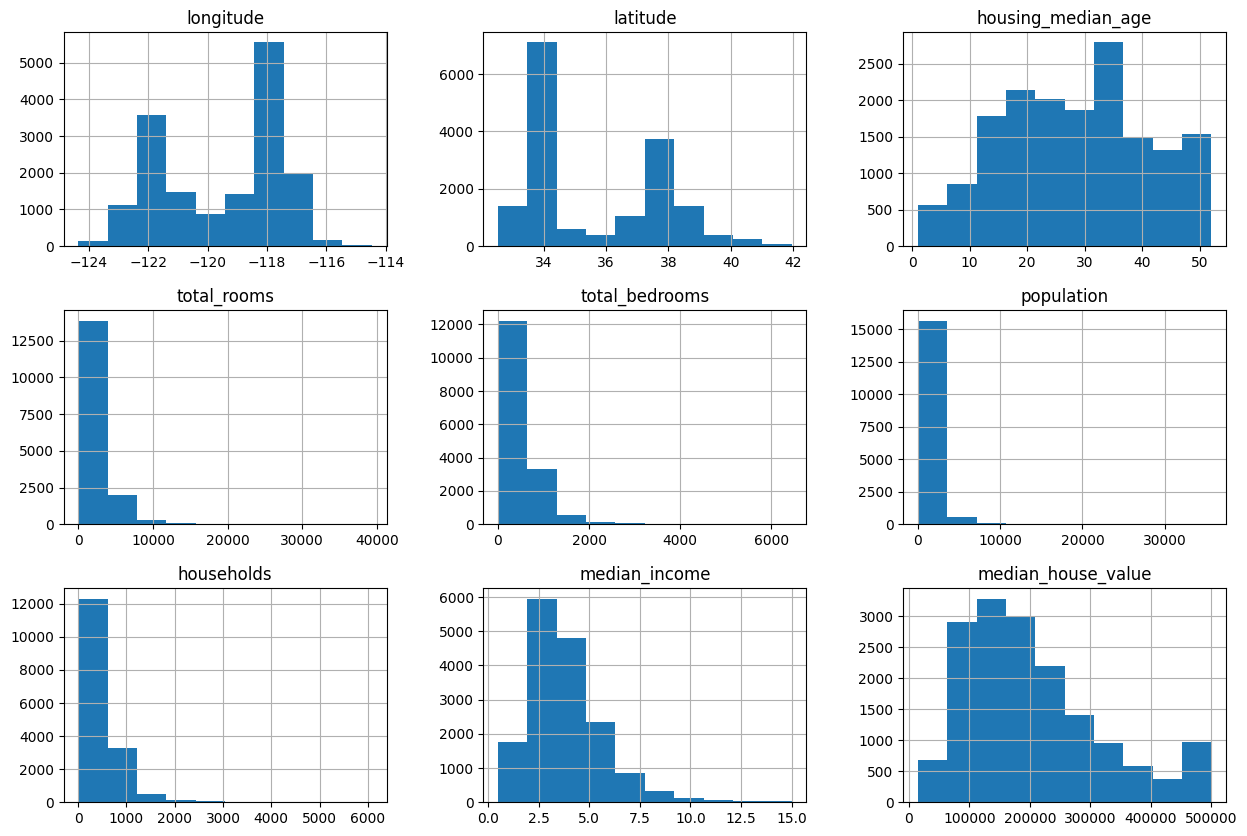

In [60]:
train_data.hist(figsize=(15,10))

<Axes: >

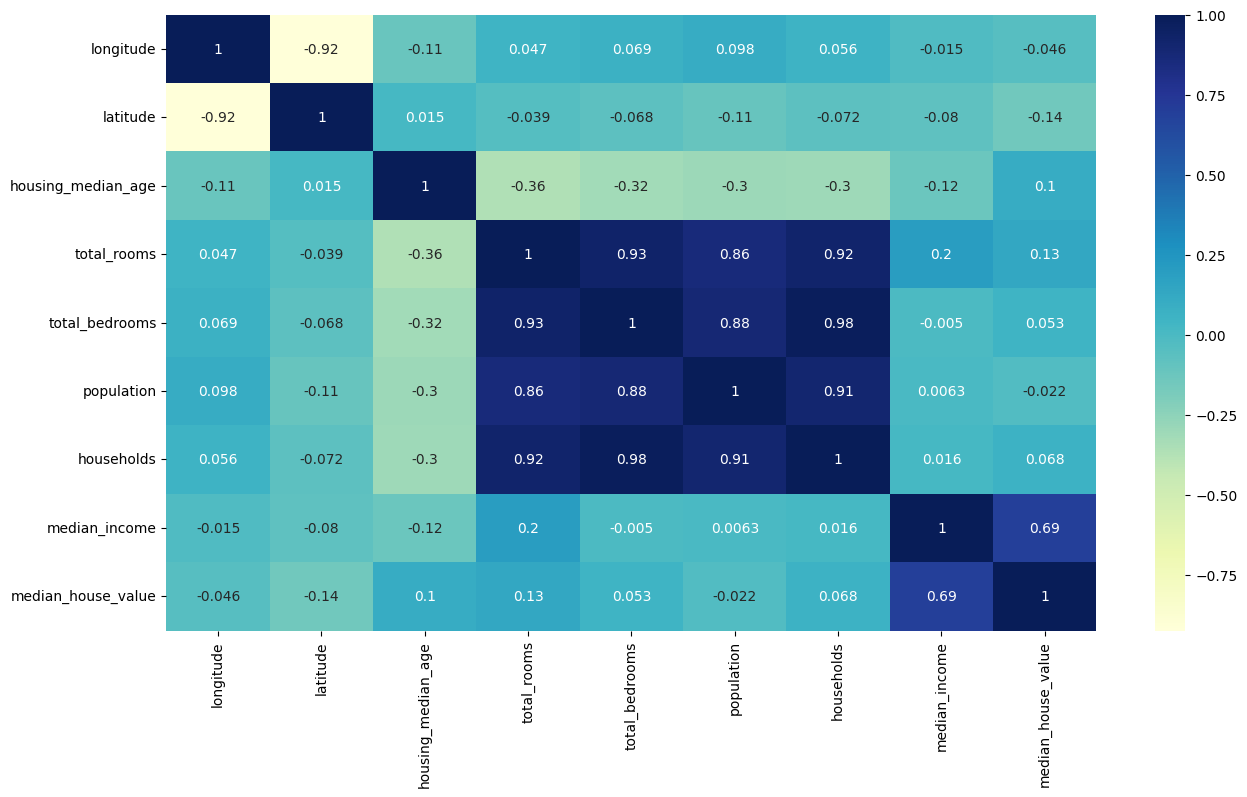

In [61]:
plt.figure(figsize = (15, 8))
sns.heatmap(train_data.drop('ocean_proximity', axis=1).corr(), annot = True, cmap="YlGnBu")

In [62]:
train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

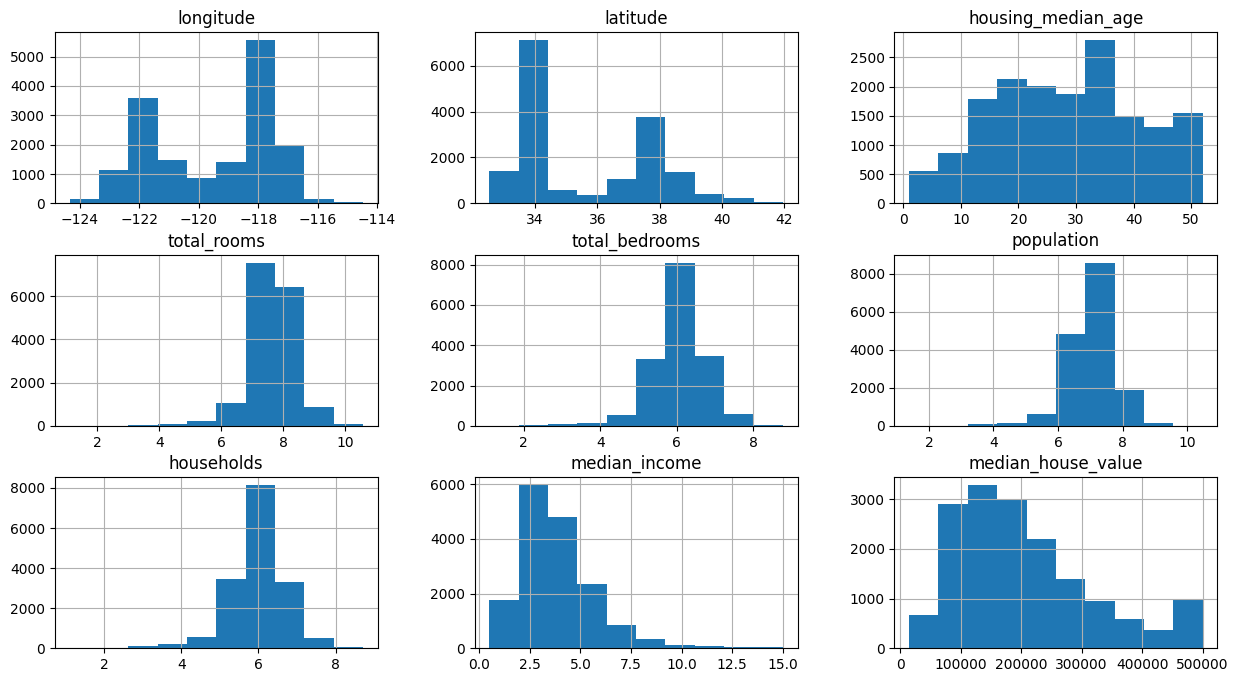

In [63]:
train_data.hist(figsize = (15,8))

In [64]:
train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity).astype('int64')).drop('ocean_proximity', axis='columns')

In [65]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
8555,-118.40,33.92,25,7.282074,5.605802,6.545350,5.648974,5.9499,345800,1,0,0,0,0
16243,-121.30,37.98,39,8.124447,6.492240,7.236339,6.448889,2.6364,93800,0,1,0,0,0
17227,-119.74,34.44,27,7.132498,5.645447,6.222576,5.648974,2.8000,353000,0,0,0,0,1
16959,-122.30,37.54,39,8.364741,7.001246,7.472501,6.895683,2.9405,340500,0,0,0,0,1
9896,-122.26,38.29,10,6.877296,5.081404,6.180017,5.198497,6.5799,218100,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15458,-117.26,33.18,9,8.420903,6.677083,7.712444,6.616065,4.5781,225600,0,0,0,0,1
6875,-118.11,34.07,39,7.147559,5.703782,6.979145,5.631212,3.3088,186600,1,0,0,0,0
2421,-119.45,36.58,18,7.262629,5.638355,6.625392,5.587249,3.7813,87300,0,1,0,0,0
7164,-118.17,34.06,36,6.770789,5.308268,7.959625,5.204007,2.1845,123800,1,0,0,0,0


<Axes: >

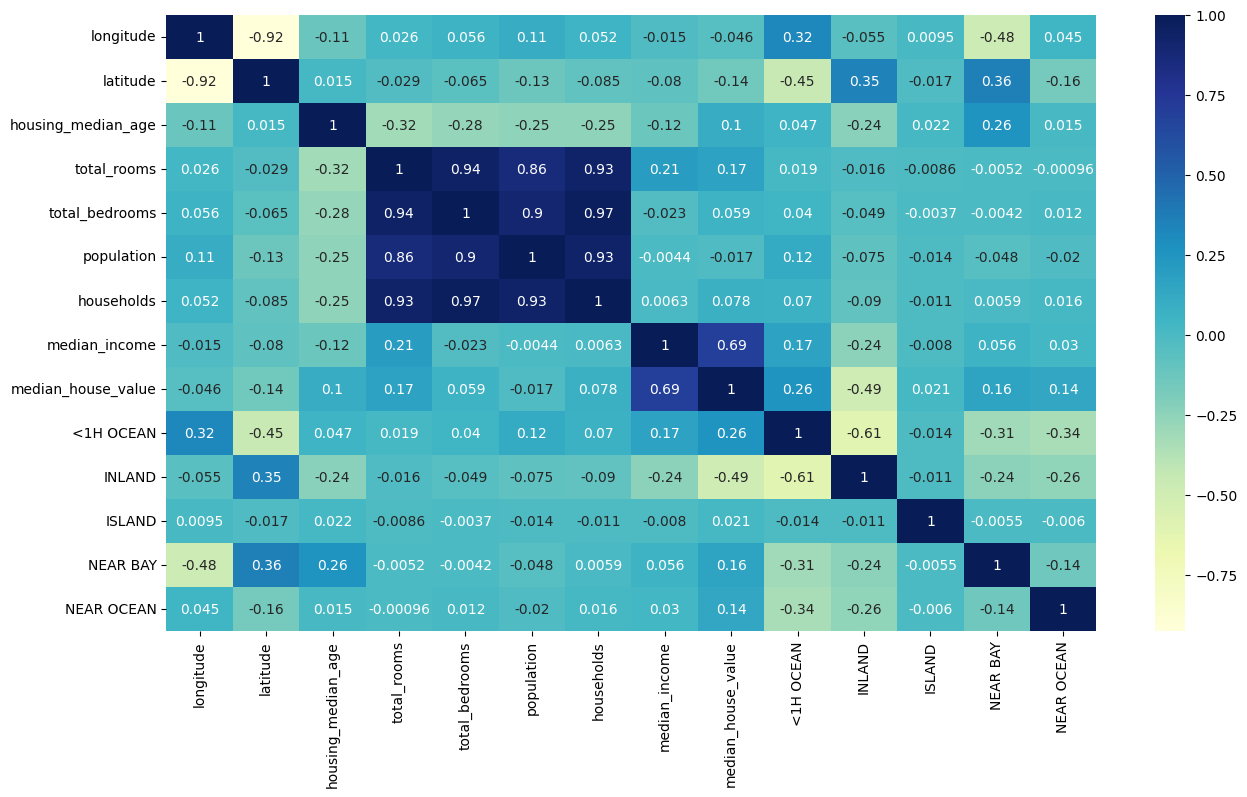

In [66]:
plt.figure(figsize = (15, 8))
sns.heatmap(train_data.corr(), annot = True, cmap="YlGnBu")

<Axes: xlabel='longitude', ylabel='latitude'>

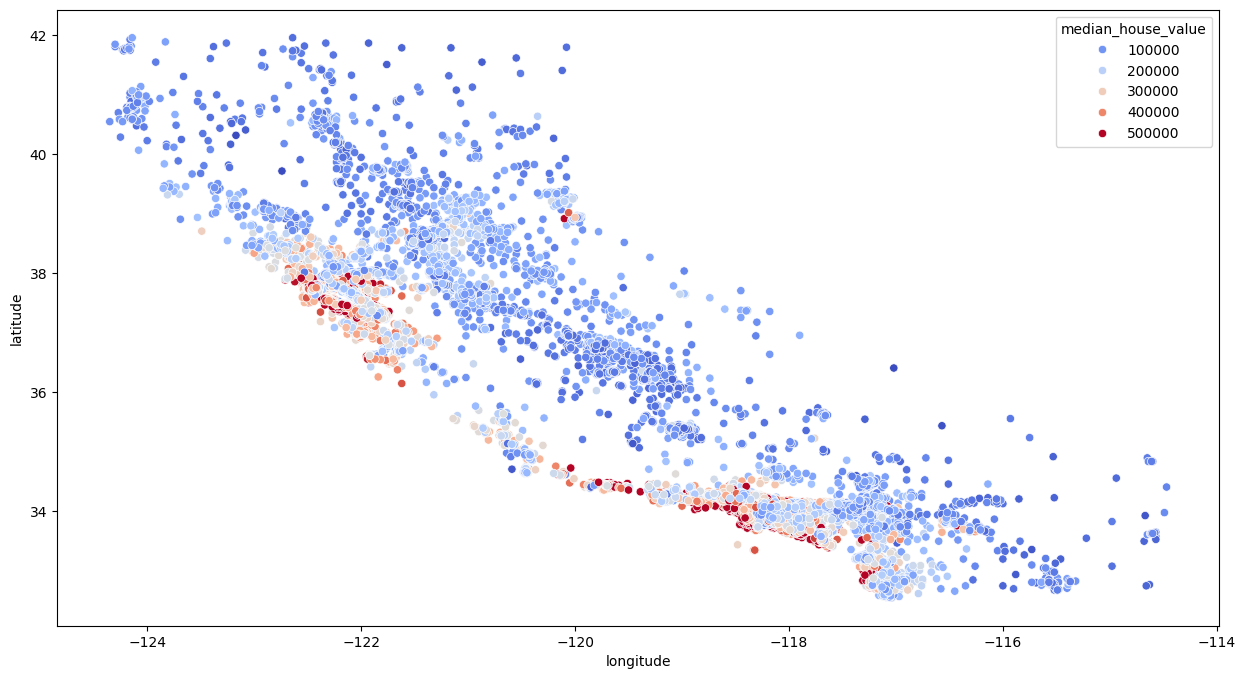

In [67]:
plt.figure(figsize = (15,8))
sns.scatterplot(x = 'longitude', y = 'latitude', data = train_data, hue = 'median_house_value', palette = 'coolwarm')

In [68]:
train_data['bedrooms_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['households_ratio'] = train_data['total_rooms'] / train_data['households']

<Axes: >

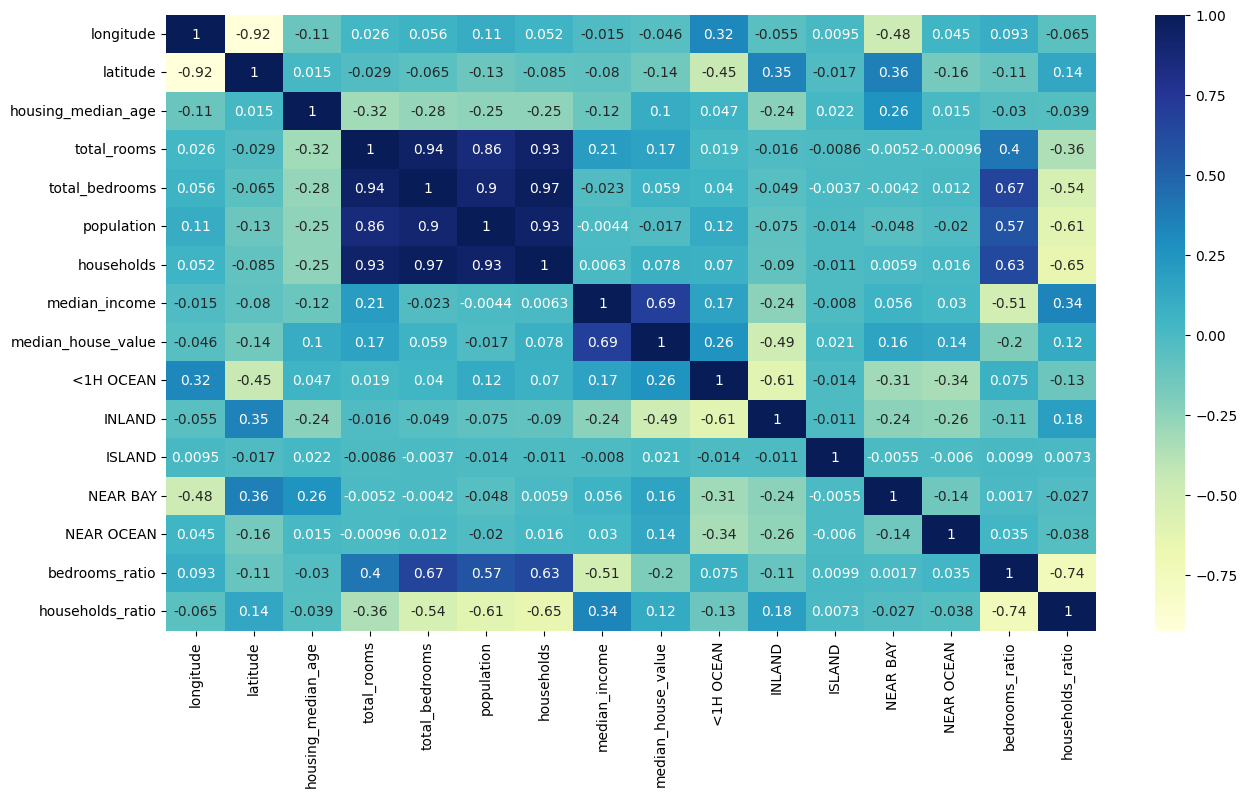

In [69]:
plt.figure(figsize = (15, 8))
sns.heatmap(train_data.corr(), annot = True, cmap="YlGnBu")

In [70]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train, y_train = train_data.drop(['median_house_value'], axis = 1), train_data['median_house_value']
X_train_s = scaler.fit_transform(X_train)

reg = LinearRegression()

reg.fit(X_train_s, y_train)

LinearRegression()

In [71]:
test_data = X_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1)

test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity).astype('int64')).drop('ocean_proximity', axis='columns')

test_data['bedrooms_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['households_ratio'] = test_data['total_rooms'] / test_data['households']

In [72]:
test_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedrooms_ratio,households_ratio
15390,-117.00,33.29,17,7.637234,5.749393,6.352629,5.402677,8.2531,419200,1,0,0,0,0,0.752811,1.413602
15756,-122.43,37.77,52,8.178639,6.725034,7.446001,6.669498,3.3702,335700,0,0,0,1,0,0.822268,1.226275
8871,-118.41,34.06,43,7.888335,6.322565,6.923629,6.228511,4.1411,500001,1,0,0,0,0,0.801508,1.266488
16053,-122.48,37.76,52,7.520776,5.820083,6.923629,5.823046,4.1397,331300,0,0,0,1,0,0.773867,1.291554
5395,-118.37,34.04,25,6.297109,5.087596,6.093570,4.882802,2.2500,333300,1,0,0,0,0,0.807926,1.289651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9934,-122.31,38.27,34,7.466799,5.652489,6.664409,5.717028,4.3585,194400,0,0,0,1,0,0.757016,1.306063
12010,-117.55,33.90,21,7.517521,5.783825,6.770789,5.730100,3.4459,198800,0,1,0,0,0,0.769379,1.311935
9146,-118.50,34.45,25,7.163172,5.252273,6.536692,5.379897,6.0097,220200,1,0,0,0,0,0.733233,1.331470
15083,-116.96,32.80,19,8.428362,7.050123,8.021585,6.964136,2.0650,124100,1,0,0,0,0,0.836476,1.210252


In [73]:
X_test, y_test = test_data.drop(['median_house_value'], axis = 1), test_data['median_house_value']

In [74]:
X_test_s = scaler.transform(X_test)


In [75]:
reg.score(X_test_s, y_test)

0.6533382302066211

In [77]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()

forest.fit(X_train_s, y_train)

RandomForestRegressor()

In [78]:
forest.score(X_test_s, y_test)

0.8056202833614169